# Particle degeneracy: why resampling creates a smoothing problem

**Companion to:** `bayes_29_07_2026.tex`, §*Bayes through time: state-space models,
Kalman filtering and particle filters* — the "genealogical or path degeneracy"
paragraph.

## Historical context

The chapter states the difficulty plainly:

> "Over time, particle weights can become concentrated on only a small number of
> particles, while repeated resampling can cause apparently different present-day
> particles to share only a few earlier ancestors. This latter genealogical or path
> degeneracy makes reconstruction of earlier states — the smoothing problem —
> particularly difficult."

This notebook makes that concrete. We reuse the bootstrap particle filter and the
bearings-only tracking simulation from the previous notebook
(`02_particle_filter_tracking`), but this time we explicitly record, at every
resampling step, *which* previous particle each new particle descended from — its
ancestor. Tracing those ancestor links back to time $0$ for every particle alive at the
final time step reveals how quickly the population's diversity collapses.

Reviews of modern sequential Monte Carlo explicitly identify this as a major open
challenge for high-dimensional and long-horizon state estimation. Further reading:
Doucet, A. & Johansen, A. M. (2009), *A Tutorial on Particle Filtering and Smoothing:
Fifteen Years Later*; Kantas, N. et al. (2015), *On Particle Methods for Parameter
Estimation in State-Space Models*, Statistical Science.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from utils.plotting import set_style, save_fig, PALETTE

set_style()
NB_DIR = pathlib.Path.cwd()
rng = np.random.default_rng(2)

## Problem & data

Same simulated bearings-only tracking problem as the previous notebook: a vehicle
moving at roughly constant velocity, observed through noisy bearing angles to two fixed
beacons. Here we run it for longer ($T=60$ steps) and resample at **every** step (rather
than only when the effective sample size drops) to make the degeneracy effect clearly
visible within a short notebook — real implementations resample adaptively as in
notebook 2, which slows but does not eliminate this effect.

In [2]:
T = 60
DT = 1.0
Q_POS, Q_VEL = 0.02, 0.05
BEACONS = np.array([[0.0, 0.0], [20.0, 0.0]])
SIGMA_BEARING = np.deg2rad(8.0)  # wider than notebook 2's 1.5 deg: makes the ancestor
# collapse curve gradual rather than instantaneous, so the degeneracy effect is visible
# step-by-step rather than as a single jump to 1 ancestor
SIGMA_OUTLIER = np.deg2rad(20.0)
P_OUTLIER = 0.08

F = np.array([[1, 0, DT, 0],
              [0, 1, 0, DT],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])


def true_trajectory(rng, x0):
    xs = np.empty((T, 4))
    x = x0.copy()
    for t in range(T):
        x = F @ x + rng.normal(0, [Q_POS, Q_POS, Q_VEL, Q_VEL])
        xs[t] = x
    return xs


def bearing(pos, beacon):
    return np.arctan2(pos[1] - beacon[1], pos[0] - beacon[0])


def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


def simulate_measurements(xs, rng):
    n_beacons = len(BEACONS)
    z = np.empty((T, n_beacons))
    for t in range(T):
        for b, beacon in enumerate(BEACONS):
            true_bearing = bearing(xs[t, :2], beacon)
            noise_sd = SIGMA_OUTLIER if rng.uniform() < P_OUTLIER else SIGMA_BEARING
            z[t, b] = wrap_angle(true_bearing + rng.normal(0, noise_sd))
    return z


def bearing_log_likelihood(pred_bearings, z_t):
    diff = wrap_angle(z_t - pred_bearings)
    dens_main = (1 - P_OUTLIER) * np.exp(-0.5 * (diff / SIGMA_BEARING) ** 2) / (
        np.sqrt(2 * np.pi) * SIGMA_BEARING
    )
    dens_out = P_OUTLIER * np.exp(-0.5 * (diff / SIGMA_OUTLIER) ** 2) / (
        np.sqrt(2 * np.pi) * SIGMA_OUTLIER
    )
    return np.log(dens_main + dens_out + 1e-300)


def systematic_resample(weights, rng):
    N = len(weights)
    positions = (rng.uniform() + np.arange(N)) / N
    cumsum = np.cumsum(weights)
    cumsum[-1] = 1.0
    return np.searchsorted(cumsum, positions)


x0 = np.array([10.0, 15.0, 0.6, -0.4])
x0_guess = np.array([8.0, 12.0, 0.0, 0.0])
P0 = np.diag([4.0, 4.0, 1.0, 1.0])

xs_true = true_trajectory(rng, x0)
Z = simulate_measurements(xs_true, rng)

## Algorithm: bootstrap particle filter with ancestry tracking

Identical propagate/weight/resample loop to notebook 2, but we now use a small
particle count ($N=50$) so the full genealogy is legible in a plot, and we record, at
every step, each particle's parent index — plus a running `origin0` array giving each
current particle's ultimate ancestor at $t=0$.

In [3]:
N_PARTICLES = 50


def run_pf_with_ancestry(Z, x0_est, P0, rng, n_particles=N_PARTICLES):
    particles = rng.multivariate_normal(x0_est, P0, size=n_particles)
    weights = np.full(n_particles, 1.0 / n_particles)
    origin0 = np.arange(n_particles)  # each particle's t=0 ancestor index

    parent_idx_history = np.zeros((T, n_particles), dtype=int)
    origin0_history = np.zeros((T, n_particles), dtype=int)
    position_history = np.empty((T, n_particles, 2))
    ess_trace = np.empty(T)

    for t in range(T):
        noise = rng.normal(0, [Q_POS, Q_POS, Q_VEL, Q_VEL], size=(n_particles, 4))
        particles = particles @ F.T + noise

        log_w = np.zeros(n_particles)
        for b, beacon in enumerate(BEACONS):
            dx, dy = particles[:, 0] - beacon[0], particles[:, 1] - beacon[1]
            log_w += bearing_log_likelihood(np.arctan2(dy, dx), Z[t, b])
        log_w -= log_w.max()
        weights = np.exp(log_w)
        weights /= weights.sum()
        ess_trace[t] = 1.0 / np.sum(weights ** 2)

        position_history[t] = particles[:, :2]

        # resample every step, to make degeneracy visible quickly
        idx = systematic_resample(weights, rng)
        particles = particles[idx]
        origin0 = origin0[idx]

        parent_idx_history[t] = idx
        origin0_history[t] = origin0

    return parent_idx_history, origin0_history, position_history, ess_trace


parent_idx_history, origin0_history, position_history, ess_trace = run_pf_with_ancestry(
    Z, x0_guess, P0, rng
)

n_unique_ancestors = np.array([len(np.unique(origin0_history[t])) for t in range(T)])
print("Unique surviving t=0 ancestors after 5, 20, 40, 60 steps:",
      n_unique_ancestors[[4, 19, 39, 59]])

Unique surviving t=0 ancestors after 5, 20, 40, 60 steps: [5 2 1 1]


## Diagnostics

**1. A genealogy plot.** Each thin line connects a particle at time $t$ to the particle
it was resampled from at time $t-1$. As $t$ grows, the lines funnel down onto fewer and
fewer distinct branches — exactly the "genealogical... degeneracy" the chapter
describes.

**2. Unique-ancestor collapse.** The number of distinct time-$0$ particles still
represented among the final population, as a function of the time horizon.

**3. The smoothing consequence.** The spread of *early*-time position estimates you'd
recover today, using only the ancestry of today's particles, versus the spread that
was actually present in the particle cloud back when it happened.

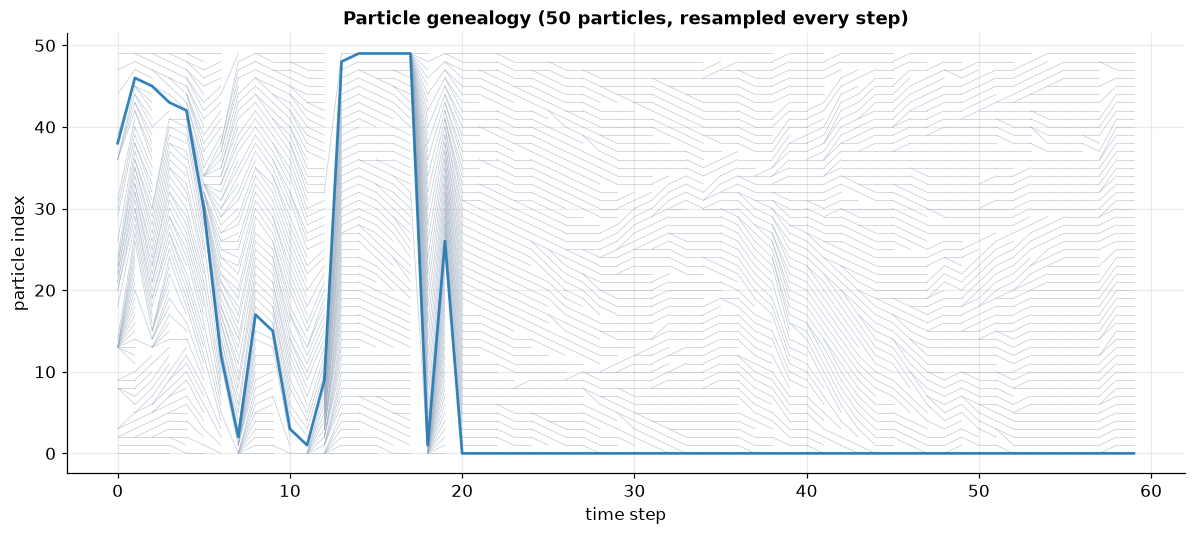

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

for t in range(1, T):
    for i in range(N_PARTICLES):
        parent = parent_idx_history[t, i]
        ax.plot([t - 1, t], [parent, i], color=PALETTE["muted"], lw=0.5, alpha=0.6)

# highlight the lineages that actually survive to the final generation
final_ancestors = np.unique(origin0_history[-1])
colors = plt.cm.tab10(np.linspace(0, 1, len(final_ancestors)))
for c, anc in zip(colors, final_ancestors):
    surviving_t = [t for t in range(T) if anc in origin0_history[t]]
    ys = []
    for t in surviving_t:
        members = np.where(origin0_history[t] == anc)[0]
        ys.append(members[0])
    ax.plot(surviving_t, ys, color=c, lw=1.8, alpha=0.9)

ax.set_xlabel("time step")
ax.set_ylabel("particle index")
ax.set_title(f"Particle genealogy ({N_PARTICLES} particles, resampled every step)")
fig.tight_layout()
save_fig(fig, "particle_genealogy", NB_DIR)
plt.show()

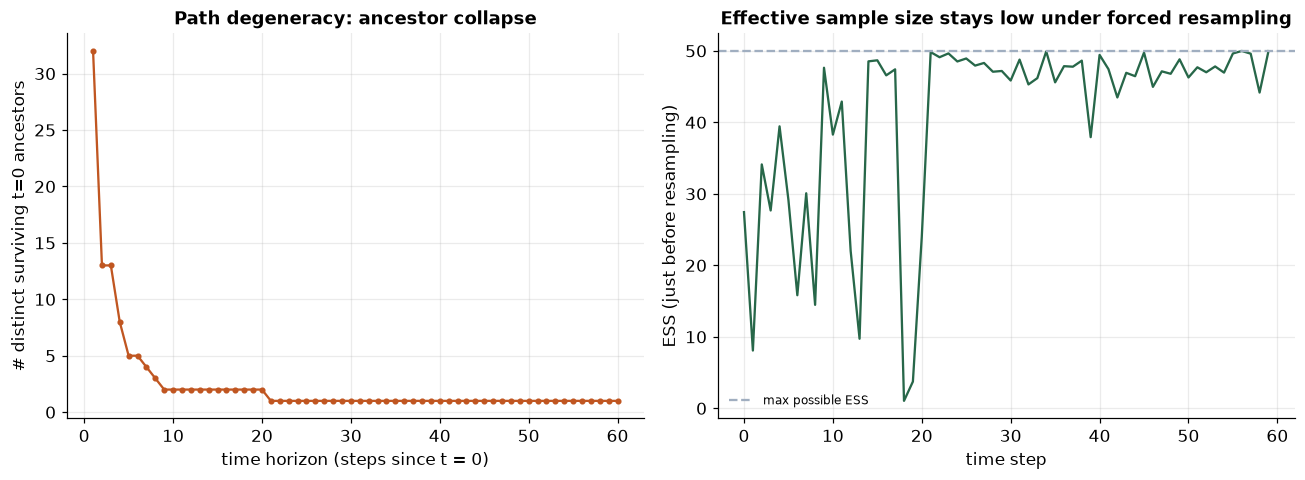

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(np.arange(1, T + 1), n_unique_ancestors, color=PALETTE["approx"], marker="o", ms=3)
axes[0].set_xlabel("time horizon (steps since t = 0)")
axes[0].set_ylabel("# distinct surviving t=0 ancestors")
axes[0].set_title("Path degeneracy: ancestor collapse")

axes[1].plot(ess_trace, color=PALETTE["accent"])
axes[1].axhline(N_PARTICLES, color=PALETTE["muted"], ls="--", label="max possible ESS")
axes[1].set_xlabel("time step")
axes[1].set_ylabel("ESS (just before resampling)")
axes[1].set_title("Effective sample size stays low under forced resampling")
axes[1].legend(fontsize=8)

fig.tight_layout()
save_fig(fig, "ancestor_collapse_and_ess", NB_DIR)
plt.show()

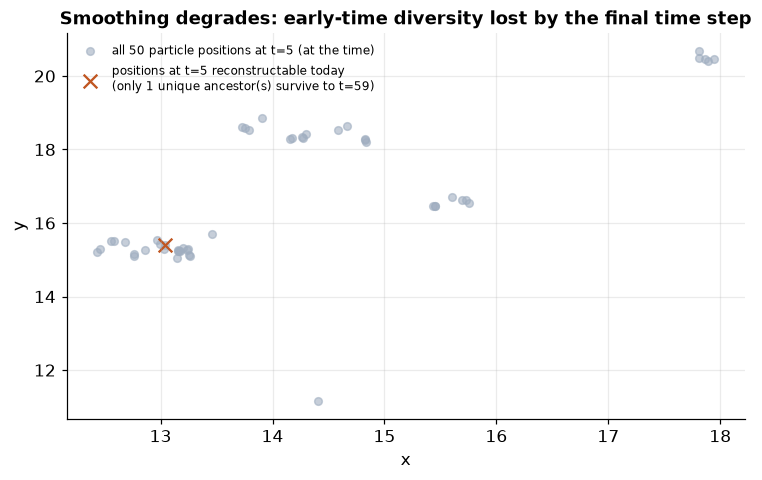

At t=5, the filter held 50 distinct position hypotheses.
By t=59, only 1 of those still have any living descendant.


In [6]:
# The smoothing consequence: what do we know about an EARLY time, using only
# the ancestry of the FINAL particle population?
t_early = 5

# (a) what the filter actually believed about position at t_early, at the time
diversity_then = position_history[t_early]

# (b) what we can reconstruct about t_early today, using only the surviving
#     ancestry of the particles alive at the final time T-1
surviving_origin_ids = origin0_history[-1]
unique_survivors = np.unique(surviving_origin_ids)
reconstructed_positions = position_history[t_early][unique_survivors]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(diversity_then[:, 0], diversity_then[:, 1], color=PALETTE["muted"], s=25,
           alpha=0.6, label=f"all {N_PARTICLES} particle positions at t={t_early} (at the time)")
ax.scatter(reconstructed_positions[:, 0], reconstructed_positions[:, 1],
           color=PALETTE["approx"], s=80, marker="x",
           label=f"positions at t={t_early} reconstructable today\n"
                 f"(only {len(unique_survivors)} unique ancestor(s) survive to t={T-1})")
ax.set_title("Smoothing degrades: early-time diversity lost by the final time step")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
save_fig(fig, "smoothing_degradation", NB_DIR)
plt.show()

print(f"At t={t_early}, the filter held {N_PARTICLES} distinct position hypotheses.")
print(f"By t={T-1}, only {len(unique_survivors)} of those still have any living descendant.")

## Takeaways

- Filtering (estimating the *current* state) stays healthy under resampling — that's
  exactly what resampling is for, and notebook 2's particle filter tracked the true
  path well throughout.
- Smoothing (reconstructing an *earlier* state using all the data, including future
  observations) is a different problem, and it degrades sharply: every resampling step
  prunes some ancestral lineages entirely, so the population's memory of early states
  collapses onto fewer and fewer distinct values as the horizon grows.
- This is exactly why the chapter singles out particle MCMC (Andrieu, Doucet &
  Holenstein, 2010) as an important later development — it addresses this same
  degeneracy problem by embedding particle filters inside an MCMC scheme rather than
  relying on a single forward pass of resampling.